# 🏥 Newborn Biometric Identification System (NBIS)
## Fingerprint Identification using Siamese Neural Networks + FAISS

**Dataset:** SOCOFing — Sokoto Coventry Fingerprint Dataset (Real images only)  
**Model:** MobileNetV2 Backbone + Triplet Loss  
**Similarity Search:** FAISS (IndexFlatIP with L2-normalized embeddings)  
**Academic Context:** Graduation Project — Thebes Higher Institute of Computer & Management Sciences

---

### Pipeline Overview
```
Raw Images → Parse Metadata → Subject-Level Split → Egyptian DB
    → Preprocessing & Augmentation → Triplet Generation
        → Siamese Network Training → Embedding Extraction
            → FAISS Index → Evaluation (ROC/EER/FAR/FRR) → Inference
```

---
## Section 0 — Install Dependencies

In [1]:
# Install required packages
import subprocess, sys

packages = [
    'faiss-cpu',
    'tqdm',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'pandas',
    'numpy',
    'Pillow',
    'faker',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


---
## Section 1 — Imports & Configuration

In [2]:
!unzip -q Real.zip -d /content/

In [3]:
import os
import re
import json
import random
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import faiss

from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from tqdm import tqdm
from collections import defaultdict
from faker import Faker

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ─── Configuration ───────────────────────────────────────────────────────────
CONFIG = {
    'dataset_path'       : '/content/Real',
    'img_size'           : (224, 224),
    'embedding_dim'      : 128,
    'batch_size'         : 16,
    'epochs'             : 30,
    'margin'             : 0.3,    # ← was 0.3 in run 1
    'lr'                 : 1e-4,
    'train_ratio'        : 0.70,
    'val_ratio'          : 0.15,
    'test_ratio'         : 0.15,
    'triplets_per_anchor': 2,      # ← was 2 in run 1
    'output_dir'         : './nbis_artifacts',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('✅ Configuration loaded.')
print(json.dumps(CONFIG, indent=2))

✅ Configuration loaded.
{
  "dataset_path": "/content/Real",
  "img_size": [
    224,
    224
  ],
  "embedding_dim": 128,
  "batch_size": 16,
  "epochs": 30,
  "margin": 0.3,
  "lr": 0.0001,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "triplets_per_anchor": 2,
  "output_dir": "./nbis_artifacts"
}


---
## Section 2 — Dataset Loading & Metadata Parsing

SOCOFing filenames follow the pattern:  
`{subject_id}__{gender}__{hand}__{finger}.BMP`  
e.g., `001__M__Left_index_finger.BMP`

We use **only the Real folder** and ignore all altered variants.

In [4]:
def parse_socofing_filename(filepath: str) -> dict | None:
    fname = Path(filepath).stem
    # Correct pattern: 466__F_Right_index_finger
    pattern = r'^(\d+)__([MF])_(Left|Right)_(\w+)_finger$'
    match = re.match(pattern, fname)
    if not match:
        return None

    return {
        'path'      : filepath,
        'subject_id': match.group(1).zfill(3),
        'gender'    : match.group(2),
        'hand'      : match.group(3),
        'finger'    : match.group(4),
    }

def load_dataset(real_folder: str) -> pd.DataFrame:
    """
    Scan the Real folder of SOCOFing and build a metadata DataFrame.
    Only .BMP files in the Real directory are considered.
    """
    records = []
    real_path = Path(real_folder)

    if not real_path.exists():
        raise FileNotFoundError(
            f'Dataset folder not found: {real_folder}\n'
            'Please update CONFIG["dataset_path"] to point to SOCOFing/Real/'
        )

    all_files = list(real_path.glob('*.BMP')) + list(real_path.glob('*.bmp'))

    for fp in tqdm(all_files, desc='Parsing filenames'):
        parsed = parse_socofing_filename(str(fp))
        if parsed:
            records.append(parsed)

    df = pd.DataFrame(records)
    df['subject_id'] = df['subject_id'].astype(str)
    df = df.sort_values('subject_id').reset_index(drop=True)

    print(f'\n✅ Dataset loaded:')
    print(f'   Total images  : {len(df)}')
    print(f'   Unique subjects: {df["subject_id"].nunique()}')
    print(f'   Gender dist.  : {df["gender"].value_counts().to_dict()}')
    print(f'   Hands         : {df["hand"].value_counts().to_dict()}')
    print(f'   Fingers       : {df["finger"].value_counts().to_dict()}')
    return df


df_all = load_dataset(CONFIG['dataset_path'])
df_all.head()

Parsing filenames: 100%|██████████| 6000/6000 [00:00<00:00, 127289.77it/s]


✅ Dataset loaded:
   Total images  : 6000
   Unique subjects: 600
   Gender dist.  : {'M': 4770, 'F': 1230}
   Hands         : {'Left': 3000, 'Right': 3000}
   Fingers       : {'little': 1200, 'ring': 1200, 'index': 1200, 'middle': 1200, 'thumb': 1200}


,path,subject_id,gender,hand,finger
0,/content/Real/1__M_Left_little_finger.BMP,001,M,Left,little
1,/content/Real/1__M_Left_ring_finger.BMP,001,M,Left,ring
2,/content/Real/1__M_Right_index_finger.BMP,001,M,Right,index
3,/content/Real/1__M_Right_little_finger.BMP,001,M,Right,little
4,/content/Real/1__M_Left_middle_finger.BMP,001,M,Left,middle


---
## Section 3 — Leakage-Free Subject-Level Split

> ⚠️ **Critical:** We split by **subject_id**, never by image.  
> This guarantees no subject appears in more than one split.

In [5]:
def subject_level_split(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio: float   = 0.15,
    test_ratio: float  = 0.15,
    seed: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split dataset at the subject level to prevent data leakage.
    Returns (df_train, df_val, df_test).
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        'Ratios must sum to 1.0'

    all_subjects = df['subject_id'].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(all_subjects)

    n = len(all_subjects)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_subjects = set(all_subjects[:n_train])
    val_subjects   = set(all_subjects[n_train:n_train + n_val])
    test_subjects  = set(all_subjects[n_train + n_val:])

    df_train = df[df['subject_id'].isin(train_subjects)].reset_index(drop=True)
    df_val   = df[df['subject_id'].isin(val_subjects)].reset_index(drop=True)
    df_test  = df[df['subject_id'].isin(test_subjects)].reset_index(drop=True)

    # Verify no leakage
    assert train_subjects.isdisjoint(val_subjects), '❌ Leakage: train ∩ val'
    assert train_subjects.isdisjoint(test_subjects), '❌ Leakage: train ∩ test'
    assert val_subjects.isdisjoint(test_subjects), '❌ Leakage: val ∩ test'

    print('✅ Leakage-free subject-level split complete:')
    print(f'   TRAIN : {len(train_subjects):4d} subjects | {len(df_train):5d} images')
    print(f'   VAL   : {len(val_subjects):4d} subjects | {len(df_val):5d} images')
    print(f'   TEST  : {len(test_subjects):4d} subjects | {len(df_test):5d} images')

    return df_train, df_val, df_test


df_train, df_val, df_test = subject_level_split(
    df_all,
    CONFIG['train_ratio'],
    CONFIG['val_ratio'],
    CONFIG['test_ratio'],
)

✅ Leakage-free subject-level split complete:
   TRAIN :  420 subjects |  4200 images
   VAL   :   90 subjects |   900 images
   TEST  :   90 subjects |   900 images


---
## Section 4 — Realistic Egyptian Database

We construct a synthetic but realistic Egyptian database with three relational tables:
- **parents** — Egyptian personal info linked to each subject
- **subjects** — biometric subject records
- **images** — each image linked to subject_id and parent_id

In [13]:
import os
os.makedirs('/content/nbis_database', exist_ok=True)
print('✅ Folder created')

✅ Folder created


In [14]:
import sqlite3
import random
import pandas as pd

# ─── Egyptian Data ────────────────────────────────────────────────────────────
FIRST_NAMES_M = [
    'Mohamed', 'Ahmed', 'Mahmoud', 'Omar', 'Ali', 'Hassan', 'Hussein',
    'Ibrahim', 'Khaled', 'Youssef','Tarek', 'Amr', 'Mostafa', 'Karim',
    'Marwan', 'Sherif', 'Hany', 'Wael', 'Ramy', 'Samir', 'Adel', 'Walid',
    'Tamer', 'Ashraf', 'Essam', 'Magdy', 'Nader', 'Osama', 'Hazem', 'Fady'
]
FIRST_NAMES_F = [
    'Fatima', 'Nour', 'Sara', 'Mariam', 'Aya', 'Hana', 'Rania', 'Dina',
    'Laila', 'Yasmin', 'Amira', 'Rana', 'Maha', 'Nada', 'Rahma',
    'Haneen', 'Sana', 'Reem', 'Heba', 'Noha', 'Eman', 'Ghada', 'Mona',
    'Nevine', 'Sherine', 'Doaa', 'Asmaa', 'Samar', 'Rasha', 'Ola'
]
LAST_NAMES = [
    'El-Sayed', 'Hassan', 'Ibrahim', 'Mohamed', 'Ali', 'Ahmed', 'Omar',
    'Mahmoud', 'Khalil', 'Farouk', 'Mansour', 'Gamal', 'El-Naggar',
    'Abdel-Fattah', 'El-Shafei', 'Morsi', 'Saleh', 'Nasser', 'Ramadan',
    'El-Din', 'Badawi', 'Zaki', 'El-Mahdy', 'Ateya', 'Fouad', 'Shawky',
    'El-Masry', 'Abdallah', 'El-Wakil', 'Hegazy', 'El-Sharkawy', 'Badr'
]

# ─── Cities + Hospitals (realistic Egyptian hospitals per city) ───────────────
CITY_HOSPITALS = {
    'Cairo': [
        'Kasr Al-Ainy Hospital',
        'Cairo University Hospital',
        'Al-Galaa Military Hospital',
        'Ain Shams University Hospital',
        'El-Demerdash Hospital',
        'Sayed Galal Hospital',
    ],
    'Giza': [
        'Ahmed Maher Teaching Hospital',
        'El-Haram Hospital',
        'Omm El-Masryeen Hospital',
        'Giza General Hospital',
    ],
    'Alexandria': [
        'Alexandria University Hospital',
        'El-Shatby Maternity Hospital',
        'El-Moassat Hospital',
        'Smouha Medical Center',
    ],
    'Mansoura': [
        'Mansoura University Hospital',
        'Mansoura General Hospital',
        'Zagazig University Hospital',
    ],
    'Tanta': [
        'Tanta University Hospital',
        'Tanta General Hospital',
        'El-Menshawy Hospital',
    ],
    'Aswan': [
        'Aswan University Hospital',
        'Aswan General Hospital',
        'Aswan Military Hospital',
    ],
    'Luxor': [
        'Luxor General Hospital',
        'Luxor International Hospital',
        'South Valley University Hospital',
    ],
    'Asyut': [
        'Asyut University Hospital',
        'Asyut General Hospital',
        'Al-Rajhi Liver Hospital',
    ],
    'Ismailia': [
        'Suez Canal University Hospital',
        'Ismailia General Hospital',
        'El-Nasr Hospital Ismailia',
    ],
    'Port Said': [
        'Port Said General Hospital',
        'Port Fouad Hospital',
        'Canal Teaching Hospital',
    ],
    'Suez': [
        'Suez General Hospital',
        'El-Arbaeen Hospital',
        'Suez Military Hospital',
    ],
    'Zagazig': [
        'Zagazig University Hospital',
        'Zagazig General Hospital',
        'Sharkia Teaching Hospital',
    ],
    'Minya': [
        'Minya University Hospital',
        'Minya General Hospital',
        'El-Minya Teaching Hospital',
    ],
    'Sohag': [
        'Sohag University Hospital',
        'Sohag General Hospital',
        'Sohag Teaching Hospital',
    ],
    'Beni Suef': [
        'Beni Suef University Hospital',
        'Beni Suef General Hospital',
    ],
    'Hurghada': [
        'Hurghada General Hospital',
        'El-Gouna Hospital',
        'Red Sea University Hospital',
    ],
    'Sharm El-Sheikh': [
        'Sharm El-Sheikh International Hospital',
        'South Sinai General Hospital',
    ],
}

CITIES = list(CITY_HOSPITALS.keys())

BLOOD_GROUPS = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
CHILD_NAMES  = ['Youssef', 'Omar', 'Adam', 'Ziad', 'Kareem', 'Hamza',
                'Nour', 'Lina', 'Reem', 'Jana', 'Salma', 'Hana']

def make_national_id(gender='M', rng=None):
    if rng is None:
        rng = random.Random()
    year  = str(rng.randint(70, 99)).zfill(2)
    month = str(rng.randint(1, 12)).zfill(2)
    day   = str(rng.randint(1, 28)).zfill(2)
    gov   = str(rng.randint(1, 27)).zfill(2)
    seq   = rng.randint(100, 999)
    if gender == 'M' and seq % 2 == 0:
        seq += 1
    elif gender == 'F' and seq % 2 != 0:
        seq += 1
    check = rng.randint(1, 9)
    return f'2{year}{month}{day}{gov}{seq:03d}0{check}'

def make_phone(rng):
    prefix = rng.choice(['010', '011', '012', '015'])
    return f'+20{prefix[1:]}{rng.randint(10000000, 99999999)}'

def make_email(first, last, rng):
    domain = rng.choice(['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com'])
    clean  = last.lower().replace('-', '').replace(' ', '')
    return f'{first.lower()}.{clean}{rng.randint(1, 99)}@{domain}'

def make_birth_date(rng, year_range=(1975, 1998)):
    y = rng.randint(*year_range)
    m = rng.randint(1, 12)
    d = rng.randint(1, 28)
    return f'{d:02d}/{m:02d}/{y}'

def make_child_birth_date(rng):
    y = rng.randint(2020, 2025)
    m = rng.randint(1, 12)
    d = rng.randint(1, 28)
    h = rng.randint(0, 23)
    mn= rng.randint(0, 59)
    return f'{d:02d}/{m:02d}/{y} {h:02d}:{mn:02d}'

# ─── Rebuild Database ─────────────────────────────────────────────────────────
db_path = '/content/nbis_database/nbis.db'
conn    = sqlite3.connect(db_path)
cursor  = conn.cursor()

# Drop all tables
cursor.executescript('''
    DROP TABLE IF EXISTS images;
    DROP TABLE IF EXISTS subjects;
    DROP TABLE IF EXISTS fathers;
    DROP TABLE IF EXISTS mothers;
    DROP TABLE IF EXISTS hospitals;
''')

# ── Hospitals table ───────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE hospitals (
        hospital_id   TEXT PRIMARY KEY,
        hospital_name TEXT NOT NULL,
        city          TEXT NOT NULL,
        phone         TEXT,
        address       TEXT
    )
''')

# ── Mothers table ─────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE mothers (
        mother_id   TEXT PRIMARY KEY,
        full_name   TEXT NOT NULL,
        national_id TEXT UNIQUE NOT NULL,
        birth_date  TEXT,
        blood_group TEXT,
        phone       TEXT,
        email       TEXT,
        city        TEXT,
        hospital_id TEXT,
        FOREIGN KEY (hospital_id) REFERENCES hospitals(hospital_id)
    )
''')

# ── Fathers table ─────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE fathers (
        father_id   TEXT PRIMARY KEY,
        full_name   TEXT NOT NULL,
        national_id TEXT UNIQUE NOT NULL,
        birth_date  TEXT,
        blood_group TEXT,
        phone       TEXT,
        email       TEXT,
        city        TEXT
    )
''')

# ── Subjects (newborns) table ─────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE subjects (
        subject_id        TEXT PRIMARY KEY,
        full_name         TEXT NOT NULL,
        gender            TEXT NOT NULL,
        birth_datetime    TEXT,
        blood_group       TEXT,
        weight_kg         TEXT,
        mother_id         TEXT NOT NULL,
        father_id         TEXT NOT NULL,
        hospital_id       TEXT NOT NULL,
        registration_date TEXT,
        FOREIGN KEY (mother_id)   REFERENCES mothers(mother_id),
        FOREIGN KEY (father_id)   REFERENCES fathers(father_id),
        FOREIGN KEY (hospital_id) REFERENCES hospitals(hospital_id)
    )
''')

# ── Images table ──────────────────────────────────────────────────────────────
cursor.execute('''
    CREATE TABLE images (
        image_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        path       TEXT NOT NULL,
        subject_id TEXT NOT NULL,
        gender     TEXT,
        hand       TEXT,
        finger     TEXT,
        FOREIGN KEY (subject_id) REFERENCES subjects(subject_id)
    )
''')

# ─── Insert hospitals ─────────────────────────────────────────────────────────
rng = random.Random(42)
hospital_map = {}  # city → list of hospital_ids

for city, hospitals in CITY_HOSPITALS.items():
    hospital_map[city] = []
    for i, hname in enumerate(hospitals):
        hid   = f'H_{city[:3].upper()}_{i+1:02d}'
        phone = make_phone(rng)
        addr  = f'{rng.randint(1,200)} {rng.choice(["El-Nasr St","El-Tahrir Sq","El-Gomhoria St","El-Horreya Rd"])}, {city}'
        cursor.execute(
            'INSERT INTO hospitals VALUES (?,?,?,?,?)',
            (hid, hname, city, phone, addr)
        )
        hospital_map[city].append(hid)

print(f'✅ Hospitals inserted: {sum(len(v) for v in hospital_map.values())}')

# ─── Insert parents and subjects ──────────────────────────────────────────────
subjects_list = df_all['subject_id'].unique()
rng           = random.Random(42)

for idx, subject_id in enumerate(subjects_list):
    # Subject gender from data
    subj_rows = df_all[df_all['subject_id'] == subject_id]
    gender    = subj_rows['gender'].iloc[0]

    # ── City and hospital (same for both parents and child) ───────────────────
    city        = rng.choice(CITIES)
    hospital_id = rng.choice(hospital_map[city])

    # ── Father ────────────────────────────────────────────────────────────────
    father_id    = f'F{str(idx+1).zfill(4)}'
    father_last  = rng.choice(LAST_NAMES)
    father_first = rng.choice(FIRST_NAMES_M)
    father_name  = f'{father_first} {father_last}'
    cursor.execute('INSERT OR IGNORE INTO fathers VALUES (?,?,?,?,?,?,?,?)', (
        father_id,
        father_name,
        make_national_id('M', rng),
        make_birth_date(rng, (1970, 1990)),
        rng.choice(BLOOD_GROUPS),
        make_phone(rng),
        make_email(father_first, father_last, rng),
        city,
    ))

    # ── Mother ────────────────────────────────────────────────────────────────
    mother_id    = f'M{str(idx+1).zfill(4)}'
    mother_first = rng.choice(FIRST_NAMES_F)
    mother_last  = rng.choice(LAST_NAMES)
    mother_name  = f'{mother_first} {mother_last}'
    cursor.execute('INSERT OR IGNORE INTO mothers VALUES (?,?,?,?,?,?,?,?,?)', (
        mother_id,
        mother_name,
        make_national_id('F', rng),
        make_birth_date(rng, (1975, 1995)),
        rng.choice(BLOOD_GROUPS),
        make_phone(rng),
        make_email(mother_first, mother_last, rng),
        city,
        hospital_id,
    ))

    # ── Child (newborn) ───────────────────────────────────────────────────────
    # Child last name = father's last name (Egyptian tradition)
    child_firsts = FIRST_NAMES_M if gender == 'M' else FIRST_NAMES_F
    child_name   = f'{rng.choice(child_firsts)} {father_first} {father_last}'
    weight       = f'{rng.uniform(2.5, 4.2):.2f} kg'
    birth_dt     = make_child_birth_date(rng)

    cursor.execute('INSERT OR IGNORE INTO subjects VALUES (?,?,?,?,?,?,?,?,?,?)', (
        subject_id,
        child_name,
        gender,
        birth_dt,
        rng.choice(BLOOD_GROUPS),
        weight,
        mother_id,
        father_id,
        hospital_id,
        birth_dt[:10],
    ))

print(f'✅ Subjects inserted : {len(subjects_list)}')
print(f'✅ Fathers inserted  : {len(subjects_list)}')
print(f'✅ Mothers inserted  : {len(subjects_list)}')

# ─── Insert images ────────────────────────────────────────────────────────────
for _, row in df_all.iterrows():
    cursor.execute(
        'INSERT INTO images (path, subject_id, gender, hand, finger) VALUES (?,?,?,?,?)',
        (row['path'], row['subject_id'], row['gender'], row['hand'], row['finger'])
    )

print(f'✅ Images inserted   : {len(df_all)}')

conn.commit()

# ─── Verify with JOIN ─────────────────────────────────────────────────────────
print('\n--- Sample Record ---')
result = pd.read_sql_query('''
    SELECT
        s.subject_id,
        s.full_name    AS child_name,
        s.gender,
        s.birth_datetime,
        s.weight_kg,
        s.blood_group  AS child_blood,
        f.full_name    AS father_name,
        f.national_id  AS father_nid,
        f.phone        AS father_phone,
        m.full_name    AS mother_name,
        m.national_id  AS mother_nid,
        m.phone        AS mother_phone,
        h.hospital_name,
        h.city
    FROM subjects s
    JOIN fathers  f ON s.father_id   = f.father_id
    JOIN mothers  m ON s.mother_id   = m.mother_id
    JOIN hospitals h ON s.hospital_id = h.hospital_id
    LIMIT 5
''', conn)
conn.close()
display(result)

# ─── Download ─────────────────────────────────────────────────────────────────
from google.colab import files
files.download('/content/nbis_database/nbis.db')
print('✅ Download started!')

✅ Hospitals inserted: 54
✅ Subjects inserted : 600
✅ Fathers inserted  : 600
✅ Mothers inserted  : 600
✅ Images inserted   : 6000

--- Sample Record ---


,subject_id,child_name,gender,birth_datetime,weight_kg,child_blood,father_name,father_nid,father_phone,mother_name,mother_nid,mother_phone,hospital_name,city
0,001,Khaled Ibrahim Nasser,M,03/02/2022 12:06,2.76 kg,AB-,Ibrahim Nasser,27703240479309,+201022575562,Sana Hassan,28704232181809,+201031429110,Mansoura University Hospital,Mansoura
1,002,Ghada Magdy Saleh,F,03/11/2025 19:40,2.95 kg,B+,Magdy Saleh,27112151822707,+201119335534,Dina Ramadan,27204280449005,+201159684848,Sharkia Teaching Hospital,Zagazig
2,003,Mostafa Mostafa Hegazy,M,16/09/2021 02:48,3.12 kg,A+,Mostafa Hegazy,27811231832506,+201263843426,Rania Badawi,27611161375808,+201288461803,Asyut University Hospital,Asyut
3,004,Hany Magdy Mansour,M,25/06/2021 05:34,3.54 kg,A+,Magdy Mansour,29107200349507,+201025374874,Eman Zaki,27305140656401,+201093926371,Mansoura University Hospital,Mansoura
4,005,Adel Omar Hassan,M,04/08/2024 07:14,3.13 kg,A-,Omar Hassan,29906272641504,+201075228535,Reem Khalil,27411161827005,+201151837852,El-Arbaeen Hospital,Suez


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [15]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy(
    '/content/nbis_database/nbis.db',
    '/content/drive/MyDrive/NBIS/nbis.db'
)
print('✅ Saved to Drive!')

Mounted at /content/drive
✅ Saved to Drive!


In [17]:
from google.colab import files

# Verify first
import sqlite3
conn   = sqlite3.connect('/content/nbis_database/nbis.db')
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print('Tables:', [t[0] for t in tables])
for t in tables:
    count = conn.execute(f"SELECT COUNT(*) FROM {t[0]}").fetchone()[0]
    print(f'   {t[0]}: {count} rows')
conn.close()

# Download
files.download('/content/nbis_database/nbis.db')
print('✅ Downloading!')


Tables: ['hospitals', 'mothers', 'fathers', 'subjects', 'images', 'sqlite_sequence']
   hospitals: 54 rows
   mothers: 600 rows
   fathers: 600 rows
   subjects: 600 rows
   images: 6000 rows
   sqlite_sequence: 1 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading!


---
## Section 5 — Preprocessing & Augmentation

- **All splits:** Grayscale → Resize (224×224) → Normalize [0,1] → Stack to 3 channels  
- **Train only:** Rotation, translation, zoom, brightness, blur, noise, cutout

In [7]:
def preprocess_image(path: str, img_size: tuple = (224, 224)) -> np.ndarray:
    """
    Load a fingerprint image, convert to grayscale, resize, normalize.
    Returns a float32 numpy array of shape (H, W, 3) in [0, 1].
    """
    img = Image.open(path).convert('L')              # grayscale
    img = img.resize(img_size, Image.LANCZOS)         # resize
    arr = np.array(img, dtype=np.float32) / 255.0    # normalize
    arr = np.stack([arr, arr, arr], axis=-1)          # → (H, W, 3) for MobileNetV2
    return arr


def augment_image(arr: np.ndarray) -> np.ndarray:
    """
    Apply realistic augmentation to a fingerprint image array.
    Only applied during training. Simulates capture variation.
    """
    img = Image.fromarray((arr[:, :, 0] * 255).astype(np.uint8), mode='L')

    # Rotation ±15°
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, fillcolor=0)

    # Translation ±10%
    w, h = img.size
    tx = random.uniform(-0.10, 0.10) * w
    ty = random.uniform(-0.10, 0.10) * h
    img = img.transform(img.size, Image.AFFINE, (1, 0, tx, 0, 1, ty), fillcolor=0)

    # Zoom 0.9–1.1
    zoom = random.uniform(0.9, 1.1)
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    img = img.resize((new_w, new_h), Image.LANCZOS)
    # Crop/pad back to original size
    if zoom > 1:
        left = (new_w - w) // 2
        top  = (new_h - h) // 2
        img  = img.crop((left, top, left + w, top + h))
    else:
        canvas = Image.new('L', (w, h), 0)
        offset_x = (w - new_w) // 2
        offset_y = (h - new_h) // 2
        canvas.paste(img, (offset_x, offset_y))
        img = canvas

    # Brightness & contrast
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Light blur (50% chance)
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0, 0.8)))

    # Light Gaussian noise
    arr_aug = np.array(img, dtype=np.float32) / 255.0
    noise = np.random.normal(0, 0.02, arr_aug.shape).astype(np.float32)
    arr_aug = np.clip(arr_aug + noise, 0, 1)

    # Small cutout (30% chance) — random black rectangle
    if random.random() < 0.3:
        ch, cw = arr_aug.shape
        cut_h = random.randint(10, 30)
        cut_w = random.randint(10, 30)
        y0 = random.randint(0, ch - cut_h)
        x0 = random.randint(0, cw - cut_w)
        arr_aug[y0:y0 + cut_h, x0:x0 + cut_w] = 0

    return np.stack([arr_aug, arr_aug, arr_aug], axis=-1)


print('✅ Preprocessing and augmentation functions defined.')

✅ Preprocessing and augmentation functions defined.


### 5.1 — Visualize Sample Images

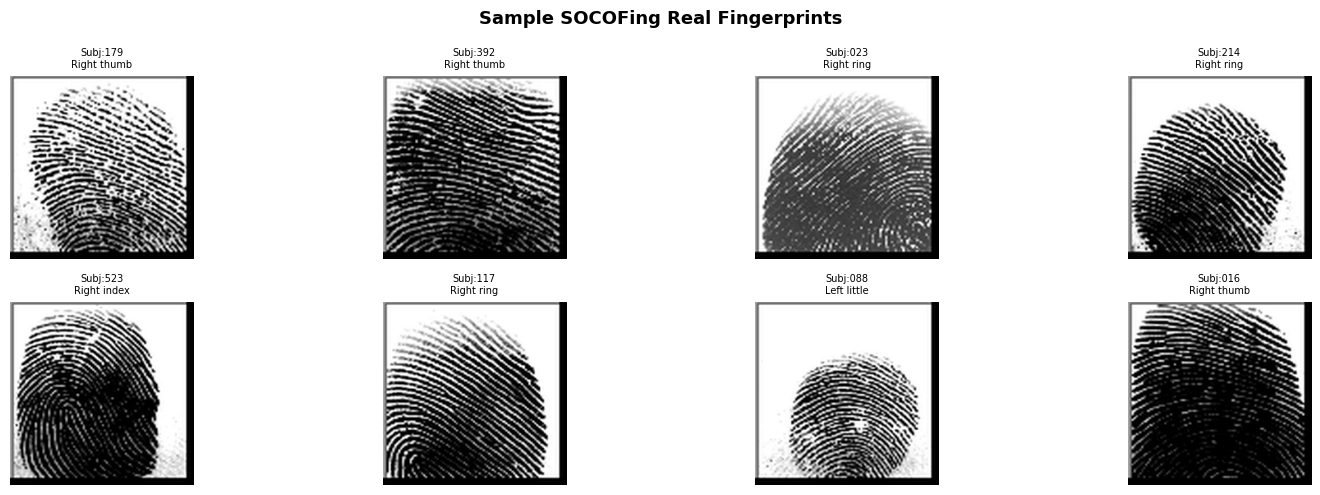

In [8]:
def visualize_samples(df: pd.DataFrame, n: int = 8, title: str = 'Sample Fingerprints'):
    """Display n random fingerprint images from the DataFrame."""
    samples = df.sample(min(n, len(df)), random_state=42)
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(samples.iterrows()):
        arr = preprocess_image(row['path'], CONFIG['img_size'])
        axes[i].imshow(arr[:, :, 0], cmap='gray')
        axes[i].set_title(f"Subj:{row['subject_id']}\n{row['hand']} {row['finger']}", fontsize=7)
        axes[i].axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_samples(df_all, n=8, title='Sample SOCOFing Real Fingerprints')

### 5.2 — Visualize Augmentation

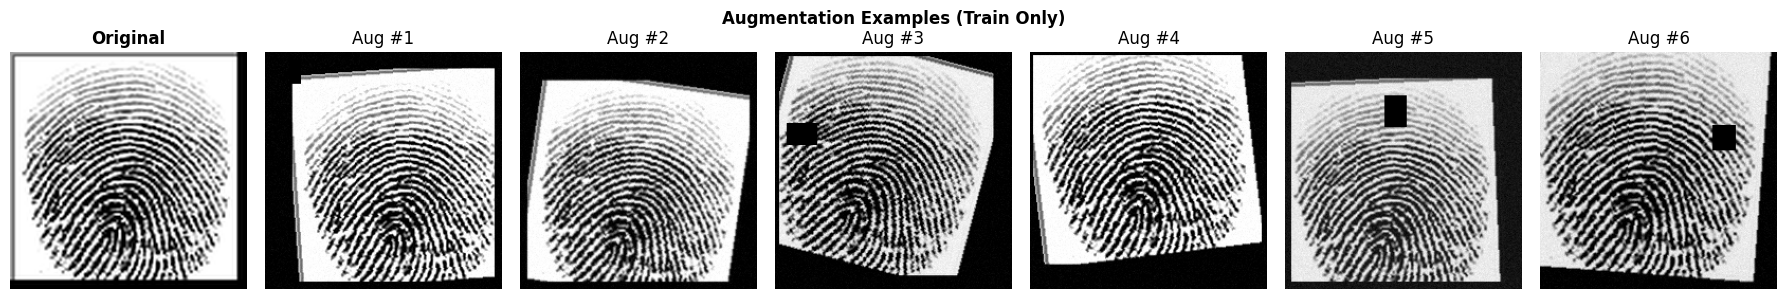

In [9]:
def visualize_augmentation(df: pd.DataFrame, n_augments: int = 6):
    """Show original vs. augmented versions of one fingerprint."""
    sample = df.sample(1, random_state=10).iloc[0]
    original = preprocess_image(sample['path'], CONFIG['img_size'])

    fig, axes = plt.subplots(1, n_augments + 1, figsize=(18, 3))
    axes[0].imshow(original[:, :, 0], cmap='gray')
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    for i in range(n_augments):
        aug = augment_image(original)
        axes[i + 1].imshow(aug[:, :, 0], cmap='gray')
        axes[i + 1].set_title(f'Aug #{i + 1}')
        axes[i + 1].axis('off')

    fig.suptitle('Augmentation Examples (Train Only)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_augmentation(df_train)

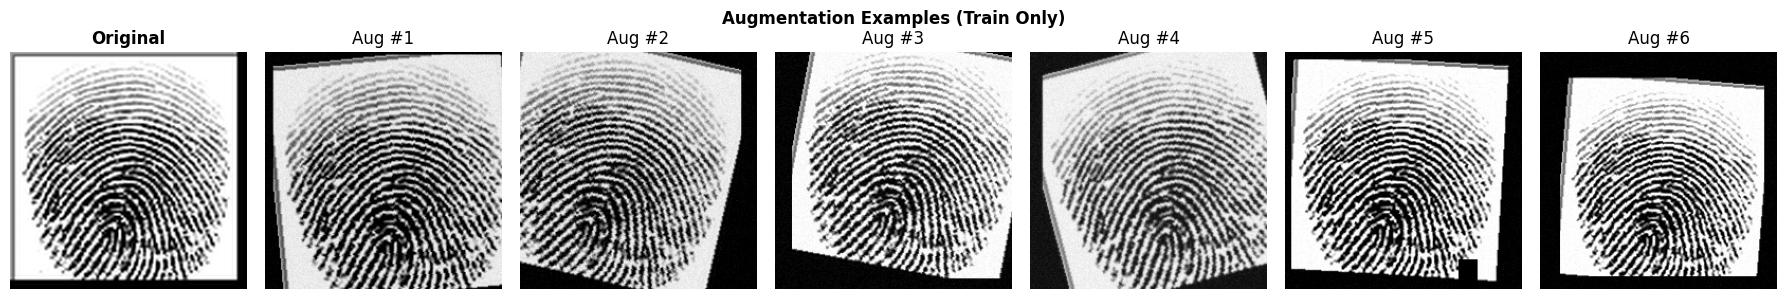

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: /content/nbis_database/augmentation_examples.png


In [10]:
from google.colab import files

# Save augmentation figure to disk
aug_path = '/content/nbis_database/augmentation_examples.png'

# Re-generate and save it
sample = df_train.sample(1, random_state=10).iloc[0]
original = preprocess_image(sample['path'], CONFIG['img_size'])

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
axes[0].imshow(original[:, :, 0], cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(6):
    aug = augment_image(original)
    axes[i + 1].imshow(aug[:, :, 0], cmap='gray')
    axes[i + 1].set_title(f'Aug #{i + 1}')
    axes[i + 1].axis('off')

fig.suptitle('Augmentation Examples (Train Only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(aug_path, dpi=150, bbox_inches='tight')
plt.show()

# Download to PC
files.download(aug_path)
print(f'✅ Downloaded: {aug_path}')

In [11]:
import os
from tqdm import tqdm
from PIL import Image
import numpy as np

# ─── Save augmented images from TRAIN set only ───────────────────────────────
AUG_PER_IMAGE = 5        # 4200 × 5 = ~21,000 augmented images
AUG_DIR       = '/content/nbis_augmented_train'
os.makedirs(AUG_DIR, exist_ok=True)

print(f'Generating {len(df_train) * AUG_PER_IMAGE} augmented images from TRAIN set only...')
print(f'Val and Test are NOT touched ✅')

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc='Augmenting TRAIN only'):
    original = preprocess_image(row['path'], CONFIG['img_size'])

    for aug_idx in range(AUG_PER_IMAGE):
        aug     = augment_image(original)
        aug_img = Image.fromarray(
            (aug[:, :, 0] * 255).astype(np.uint8), mode='L'
        )
        # Filename keeps subject_id for traceability
        fname = (
            f"{row['subject_id']}__{row['gender']}_"
            f"{row['hand']}_{row['finger']}_aug{aug_idx + 1}.png"
        )
        aug_img.save(os.path.join(AUG_DIR, fname))

total_saved = len(os.listdir(AUG_DIR))
print(f'\n✅ Saved {total_saved} augmented images')
print(f'   All from TRAIN subjects only')
print(f'   Val subjects : NOT included ✅')
print(f'   Test subjects: NOT included ✅')

# ─── Zip and download ─────────────────────────────────────────────────────────
print('\nZipping...')
zip_path = '/content/nbis_augmented_train.zip'
!zip -qr {zip_path} {AUG_DIR}

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f'✅ Zip size: {size_mb:.1f} MB')

from google.colab import files
files.download(zip_path)
print('✅ Download started!')

Generating 21000 augmented images from TRAIN set only...
Val and Test are NOT touched ✅


Augmenting TRAIN only:   1%|          | 52/4200 [00:02<03:54, 17.66it/s]


KeyboardInterrupt: 

---
## Section 6 — Triplet Generator

Each triplet consists of:
- **Anchor**: A fingerprint image from a subject
- **Positive**: A different image from the **same** subject
- **Negative**: An image from a **different** subject (hard negative: same finger type preferred)

In [11]:
AUG_DIR       = '/content/nbis_augmented_train'

In [12]:
class TripletDataset:
    """
    Generates (anchor, positive, negative) triplets from a DataFrame.
    Supports hard negative mining: prefers negatives from the same finger type.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        img_size: tuple,
        augment: bool = False,
        triplets_per_anchor: int = 3
    ):
        self.df                  = df
        self.img_size            = img_size
        self.augment             = augment
        self.triplets_per_anchor = triplets_per_anchor

        # Build index: subject → list of rows
        self.subject_map = defaultdict(list)
        for _, row in df.iterrows():
            self.subject_map[row['subject_id']].append(row)

        # Filter subjects with at least 2 images (required for anchor + positive)
        self.valid_subjects = [
            sid for sid, rows in self.subject_map.items() if len(rows) >= 2
        ]

        # Build finger-type index for hard negative mining
        self.finger_map = defaultdict(list)  # finger → [rows from other subjects]
        for _, row in df.iterrows():
            self.finger_map[row['finger']].append(row)

        print(f'✅ TripletDataset initialized:')
        print(f'   Valid subjects   : {len(self.valid_subjects)}')
        print(f'   Augmentation     : {augment}')
        print(f'   Triplets/anchor  : {triplets_per_anchor}')

    def _load(self, row) -> np.ndarray:
        arr = preprocess_image(row['path'], self.img_size)
        if self.augment:
            arr = augment_image(arr)
        return arr

    def _hard_negative(self, subject_id: str, finger: str):
        """Find a negative from the same finger type but different subject."""
        candidates = [
            r for r in self.finger_map[finger]
            if r['subject_id'] != subject_id
        ]
        if not candidates:
            # Fallback: any different subject
            neg_subject = random.choice(
                [s for s in self.valid_subjects if s != subject_id]
            )
            return random.choice(self.subject_map[neg_subject])
        return random.choice(candidates)

    def generate_triplets(
        self
    ) -> list[tuple[np.ndarray, np.ndarray, np.ndarray]]:
        """Generate all triplets for one epoch."""
        triplets = []
        for subject_id in self.valid_subjects:
            images = self.subject_map[subject_id]
            for _ in range(self.triplets_per_anchor):
                anchor_row, positive_row = random.sample(images, 2)
                finger = anchor_row['finger']
                neg_row = self._hard_negative(subject_id, finger)

                anchor   = self._load(anchor_row)
                positive = self._load(positive_row)
                negative = self._load(neg_row)

                triplets.append((anchor, positive, negative))

        random.shuffle(triplets)
        return triplets


# Instantiate datasets
# ─── Reduce memory usage ──────────────────────────────────────────────────────

# Option 1: Use original train only (no augmented df)
# Less data but won't crash
train_dataset = TripletDataset(
    df_train, CONFIG['img_size'],
    augment=True,        # ← back to on-the-fly augmentation
    triplets_per_anchor=2  # ← reduced from 3
)
val_dataset = TripletDataset(
    df_val, CONFIG['img_size'],
    augment=False,
    triplets_per_anchor=1  # ← reduced from 2
)
print('✅ Memory-safe datasets created')

✅ TripletDataset initialized:
   Valid subjects   : 420
   Augmentation     : True
   Triplets/anchor  : 2
✅ TripletDataset initialized:
   Valid subjects   : 90
   Augmentation     : False
   Triplets/anchor  : 1
✅ Memory-safe datasets created


In [13]:
def triplets_to_tf_dataset(
    triplet_dataset: TripletDataset,
    batch_size: int
) -> tf.data.Dataset:
    """
    Convert TripletDataset to a tf.data.Dataset for efficient training.
    Returns batched (anchor, positive, negative) tensors.
    """
    print('Generating triplets...')
    triplets = triplet_dataset.generate_triplets()
    anchors, positives, negatives = zip(*triplets)

    anchors   = np.array(anchors,   dtype=np.float32)
    positives = np.array(positives, dtype=np.float32)
    negatives = np.array(negatives, dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((anchors, positives, negatives))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print(f'✅ tf.data.Dataset: {len(triplets)} triplets → {len(triplets)//batch_size} batches')
    return ds


print('Triplet generators ready. Datasets will be created during training.')

Triplet generators ready. Datasets will be created during training.


---
## Section 7 — Model Architecture: Siamese Network with MobileNetV2

```
Input (224×224×3)
    └── MobileNetV2 (pretrained, no head)
        └── GlobalAveragePooling2D
            └── Dense(256) + BatchNorm + Dropout(0.3)
                └── Dense(128)  ← L2 normalized embedding
```

In [14]:
def build_embedding_network(img_size: tuple, embedding_dim: int = 128) -> Model:
    """
    Build the embedding sub-network using MobileNetV2 backbone.
    Output: L2-normalized embedding vector of shape (embedding_dim,).
    """
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    # Unfreeze top layers for fine-tuning
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    inputs = keras.Input(shape=(*img_size, 3), name='fingerprint_input')
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim)(x)
    # L2 Normalization → embeddings lie on unit hypersphere
    outputs = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name='l2_embedding'
    )(x)

    return Model(inputs, outputs, name='embedding_network')


embedding_net = build_embedding_network(CONFIG['img_size'], CONFIG['embedding_dim'])
embedding_net.summary()

trainable = sum(np.prod(v.shape) for v in embedding_net.trainable_variables)
total     = sum(np.prod(v.shape) for v in embedding_net.variables)
print(f'\nTrainable params: {trainable:,} / {total:,}')

Model: "embedding_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fingerprint_input (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_embedding (Lambda)           │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,887,744 (7.20 MB)

 Non-trainable params: 732,096 (2.79 MB)


Trainable params: 1,887,744 / 2,619,842


---
## Section 8 — Triplet Loss

$$\mathcal{L} = \max\bigl(d(A, P) - d(A, N) + \alpha,\; 0\bigr)$$

Where $d$ is the **cosine distance** (using dot product since embeddings are L2-normalized).

In [15]:
@tf.function
def triplet_loss(anchor: tf.Tensor, positive: tf.Tensor,
                 negative: tf.Tensor, margin: float = 0.3) -> tf.Tensor:
    """
    Compute Triplet Loss using cosine similarity.
    Since embeddings are L2-normalized, dot product = cosine similarity.
    Cosine distance = 1 - cosine_similarity.

    Args:
        anchor   : (batch, embedding_dim) – L2 normalized
        positive : (batch, embedding_dim) – L2 normalized
        negative : (batch, embedding_dim) – L2 normalized
        margin   : float – triplet margin alpha
    Returns:
        Scalar loss value (mean over batch)
    """
    # Cosine similarity via dot product (embeddings are unit vectors)
    sim_ap = tf.reduce_sum(anchor * positive, axis=1)  # (batch,)
    sim_an = tf.reduce_sum(anchor * negative, axis=1)  # (batch,)

    # Cosine distance = 1 - similarity
    d_ap = 1.0 - sim_ap
    d_an = 1.0 - sim_an

    loss = tf.maximum(d_ap - d_an + margin, 0.0)
    return tf.reduce_mean(loss)


print('✅ Triplet Loss function defined.')
print(f'   Margin: {CONFIG["margin"]}')

✅ Triplet Loss function defined.
   Margin: 0.3


---
## Section 9 — Training Loop

In [16]:
class TripletTrainer:
    """Custom training loop for the Siamese triplet network."""

    def __init__(
        self,
        model: Model,
        optimizer,
        margin: float,
        checkpoint_path: str
    ):
        self.model           = model
        self.optimizer       = optimizer
        self.margin          = margin
        self.checkpoint_path = checkpoint_path
        self.history         = {'train_loss': [], 'val_loss': []}
        self.best_val_loss   = float('inf')

    @tf.function
    def _train_step(self, anchor, positive, negative):
        with tf.GradientTape() as tape:
            emb_a = self.model(anchor,   training=True)
            emb_p = self.model(positive, training=True)
            emb_n = self.model(negative, training=True)
            loss  = triplet_loss(emb_a, emb_p, emb_n, self.margin)
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        return loss

    @tf.function
    def _val_step(self, anchor, positive, negative):
        emb_a = self.model(anchor,   training=False)
        emb_p = self.model(positive, training=False)
        emb_n = self.model(negative, training=False)
        return triplet_loss(emb_a, emb_p, emb_n, self.margin)

    def train(
        self,
        train_ds: TripletDataset,
        val_ds: TripletDataset,
        epochs: int,
        batch_size: int,
        patience: int = 5,
        lr_patience: int = 3,
        lr_factor: float = 0.5
    ):
        no_improve   = 0
        lr_no_improve = 0

        for epoch in range(1, epochs + 1):
            print(f'\n[Epoch {epoch}/{epochs}]')

            # Build tf.data datasets fresh each epoch (new triplets)
            train_tf = triplets_to_tf_dataset(train_ds, batch_size)
            val_tf   = triplets_to_tf_dataset(val_ds,   batch_size)

            # Training
            train_losses = []
            for anchor, positive, negative in tqdm(train_tf, desc='  Train'):
                loss = self._train_step(anchor, positive, negative)
                train_losses.append(float(loss))
            avg_train = np.mean(train_losses)

            # Validation
            val_losses = []
            for anchor, positive, negative in tqdm(val_tf, desc='  Val  '):
                loss = self._val_step(anchor, positive, negative)
                val_losses.append(float(loss))
            avg_val = np.mean(val_losses)

            self.history['train_loss'].append(avg_train)
            self.history['val_loss'].append(avg_val)

            print(f'  Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

            # ModelCheckpoint
            if avg_val < self.best_val_loss:
                self.best_val_loss = avg_val
                self.model.save(self.checkpoint_path)
                print(f'  ✅ Checkpoint saved (val_loss={avg_val:.4f})')
                no_improve    = 0
                lr_no_improve = 0
            else:
                no_improve    += 1
                lr_no_improve += 1

            # ReduceLROnPlateau
            if lr_no_improve >= lr_patience:
                old_lr = float(self.optimizer.learning_rate)
                new_lr = old_lr * lr_factor
                self.optimizer.learning_rate.assign(new_lr)
                print(f'  📉 LR reduced: {old_lr:.2e} → {new_lr:.2e}')
                lr_no_improve = 0

            # EarlyStopping
            if no_improve >= patience:
                print(f'  ⏹️  Early stopping (no improvement for {patience} epochs)')
                break

        print(f'\n✅ Training complete. Best val loss: {self.best_val_loss:.4f}')
        return self.history
checkpoint_path = os.path.join(CONFIG['output_dir'], 'nbis_best_model.keras')

# Initialize optimizer and trainer
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
trainer   = TripletTrainer(
    model           = embedding_net,
    optimizer       = optimizer,
    margin          = CONFIG['margin'],
    checkpoint_path = checkpoint_path
)



trainer = TripletTrainer(
    model=embedding_net,
    optimizer=optimizer,
    margin=CONFIG['margin'],
    checkpoint_path=checkpoint_path
)

print('✅ Trainer ready.')

✅ Trainer ready.


In [17]:
# ─── START TRAINING ──────────────────────────────────────────────────────────
history = trainer.train(
    train_ds   = train_dataset,
    val_ds     = val_dataset,
    epochs     = CONFIG['epochs'],
    batch_size = CONFIG['batch_size'],
    patience   = 7,
    lr_patience= 3,
    lr_factor  = 0.5,
)


[Epoch 1/30]
Generating triplets...
✅ tf.data.Dataset: 840 triplets → 52 batches
Generating triplets...
✅ tf.data.Dataset: 90 triplets → 5 batches


  Val  : 100%|██████████| 6/6 [00:07<00:00,  1.20s/it]


  Train Loss: 0.2550 | Val Loss: 0.2636
  ✅ Checkpoint saved (val_loss=0.2636)

[Epoch 2/30]
Generating triplets...
✅ tf.data.Dataset: 840 triplets → 52 batches
Generating triplets...
✅ tf.data.Dataset: 90 triplets → 5 batches


  Val  : 100%|██████████| 6/6 [00:00<00:00,  9.95it/s]


  Train Loss: 0.2140 | Val Loss: 0.2442
  ✅ Checkpoint saved (val_loss=0.2442)

[Epoch 3/30]
Generating triplets...
✅ tf.data.Dataset: 840 triplets → 52 batches
Generating triplets...
✅ tf.data.Dataset: 90 triplets → 5 batches


...

  Train Loss: 0.1482 | Val Loss: 0.1582

[Epoch 27/30]
Generating triplets...
✅ tf.data.Dataset: 840 triplets → 52 batches
Generating triplets...
✅ tf.data.Dataset: 90 triplets → 5 batches


  Val  : 100%|██████████| 6/6 [00:00<00:00, 10.06it/s]


  Train Loss: 0.1445 | Val Loss: 0.1117
  📉 LR reduced: 1.25e-05 → 6.25e-06

[Epoch 28/30]
Generating triplets...
✅ tf.data.Dataset: 840 triplets → 52 batches
Generating triplets...
✅ tf.data.Dataset: 90 triplets → 5 batches


  Val  : 100%|██████████| 6/6 [00:00<00:00,  9.95it/s]

  Train Loss: 0.1377 | Val Loss: 0.1659
  ⏹️  Early stopping (no improvement for 7 epochs)

✅ Training complete. Best val loss: 0.1102


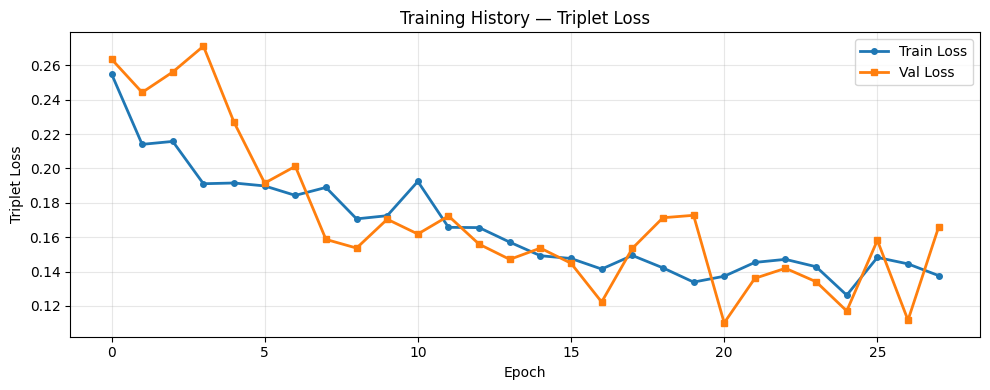

In [18]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
plt.plot(history['val_loss'],   label='Val Loss',   linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Training History — Triplet Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_history.png'), dpi=150)
plt.show()

---
## Section 10 — Load Best Model & Extract Embeddings

In [19]:
# ─── Step 1: Define custom L2 layer ──────────────────────────────────────────
class L2Normalize(keras.layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

    def get_config(self):
        return super().get_config()

# ─── Step 2: Rebuild model architecture with L2Normalize instead of Lambda ────
def build_embedding_network_v2(img_size: tuple, embedding_dim: int = 128) -> Model:
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    inputs = keras.Input(shape=(*img_size, 3), name='fingerprint_input')
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim)(x)
    outputs = L2Normalize(name='l2_embedding')(x)  # ← custom layer not Lambda

    return Model(inputs, outputs, name='embedding_network')

# ─── Step 3: Build new model and load weights from checkpoint ─────────────────
best_model = build_embedding_network_v2(CONFIG['img_size'], CONFIG['embedding_dim'])

# Load weights only (not architecture)
best_model.load_weights(checkpoint_path)

print(f'✅ Model weights loaded from: {checkpoint_path}')
print(f'   Input shape : {best_model.input_shape}')
print(f'   Output shape: {best_model.output_shape}')

# ─── Step 4: Verify L2 normalization still works ──────────────────────────────
test_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
test_output = best_model.predict(test_input, verbose=0)
norm = np.linalg.norm(test_output)
print(f'   L2 norm (should be ≈1.0): {norm:.6f}')

✅ Model weights loaded from: ./nbis_artifacts/nbis_best_model.keras
   Input shape : (None, 224, 224, 3)
   Output shape: (None, 128)
   L2 norm (should be ≈1.0): 1.000000


In [20]:
def extract_embeddings(
    df: pd.DataFrame,
    model: Model,
    img_size: tuple,
    batch_size: int = 64,
    desc: str = 'Extracting embeddings'
) -> np.ndarray:
    """
    Extract L2-normalized embeddings for all images in a DataFrame.
    Returns array of shape (N, embedding_dim).
    """
    embeddings = []
    paths = df['path'].tolist()

    for i in tqdm(range(0, len(paths), batch_size), desc=desc):
        batch_paths = paths[i: i + batch_size]
        batch_imgs  = np.array(
            [preprocess_image(p, img_size) for p in batch_paths],
            dtype=np.float32
        )
        batch_embs = model.predict(batch_imgs, verbose=0)
        embeddings.append(batch_embs)

    return np.vstack(embeddings).astype(np.float32)


# ─── Extract embeddings ───────────────────────────────────────────────────────
print('Extracting embeddings for TRAIN set (used for FAISS index)...')
train_embeddings = extract_embeddings(
    df_train, best_model, CONFIG['img_size'], desc='Train embeddings'
)

print('\nExtracting embeddings for TEST set (used for evaluation)...')
test_embeddings = extract_embeddings(
    df_test, best_model, CONFIG['img_size'], desc='Test embeddings'
)

print(f'\n✅ Train embeddings shape: {train_embeddings.shape}')
print(f'✅ Test embeddings shape : {test_embeddings.shape}')

norms = np.linalg.norm(train_embeddings[:10], axis=1)
print(f'\nL2 norms (should all be ≈1.0): {norms}')

Extracting embeddings for TRAIN set (used for FAISS index)...


Train embeddings: 100%|██████████| 66/66 [00:45<00:00,  1.44it/s]



Extracting embeddings for TEST set (used for evaluation)...


Test embeddings: 100%|██████████| 15/15 [00:15<00:00,  1.04s/it]


✅ Train embeddings shape: (4200, 128)
✅ Test embeddings shape : (900, 128)

L2 norms (should all be ≈1.0): [0.99999994 0.99999994 1.0000001  0.99999994 1.         1.
 1.         1.         1.         0.99999994]


---
## Section 11 — FAISS Index Construction

We use `IndexFlatIP` (Inner Product) which equals cosine similarity  
when embeddings are L2-normalized. This gives exact nearest-neighbor search.

In [29]:
def build_faiss_index(
    embeddings: np.ndarray,
    df_ref: pd.DataFrame,
    df_subjects: pd.DataFrame,
    df_parents: pd.DataFrame,
) -> tuple[faiss.Index, list[dict]]:
    """
    Build a FAISS IndexFlatIP index from L2-normalized embeddings.

    Returns:
        index   : FAISS index
        mapping : list of dicts {idx → subject_id, parent_id, ...}
    """
    # Ensure embeddings are float32 and L2 normalized
    embs = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)  # in-place normalization (ensures unit vectors)

    dim   = embs.shape[1]
    index = faiss.IndexFlatIP(dim)  # Inner Product ≡ Cosine for unit vectors
    index.add(embs)

    # Build subject & parent lookup
    subj_lookup   = df_subjects.set_index('subject_id').to_dict('index')
    parent_lookup = df_parents.set_index('parent_id').to_dict('index')

    mapping = []
    for i, row in df_ref.iterrows():
        sid = row['subject_id']
        pid = row.get('parent_id') or subj_lookup.get(sid, {}).get('parent_id', 'N/A')
        p_info = parent_lookup.get(pid, {})
        mapping.append({
            'faiss_idx' : len(mapping),
            'subject_id': sid,
            'parent_id' : pid,
            'full_name' : p_info.get('full_name',  'Unknown'),
            'phone'     : p_info.get('phone_number', 'N/A'),
            'email'     : p_info.get('email',       'N/A'),
            'city'      : p_info.get('city',        'N/A'),
        })

    print(f'✅ FAISS index built:')
    print(f'   Vectors in index : {index.ntotal}')
    print(f'   Embedding dim    : {dim}')
    print(f'   Index type       : IndexFlatIP (cosine similarity)')

    return index, mapping


# Build FAISS index from TRAIN embeddings
faiss_index, index_mapping = build_faiss_index(
    train_embeddings,
    df_train,
    df_subjects,
    df_parents,
)

print(f'\nSample mapping entry:')
print(index_mapping[0])

✅ FAISS index built:
   Vectors in index : 4200
   Embedding dim    : 128
   Index type       : IndexFlatIP (cosine similarity)

Sample mapping entry:
{'faiss_idx': 0, 'subject_id': '001', 'parent_id': 'P0001', 'full_name': 'Mohamed Ateya', 'phone': '+20132868828', 'email': 'mohamed.ateya29@yahoo.com', 'city': 'Ismailia'}


In [30]:
# ─── Section 11.2 — Inference FAISS Index (all subjects) ─────────────────────
# This is SEPARATE from the evaluation index
# No leakage — model weights are already frozen

print('Extracting embeddings for ALL subjects (inference index)...')
all_embeddings = extract_embeddings(
    df_all, best_model, CONFIG['img_size'], desc='All embeddings'
)
print(f'✅ All embeddings shape: {all_embeddings.shape}')

# Build inference index
faiss_inference, mapping_inference = build_faiss_index(
    all_embeddings,
    df_all,
    df_subjects,
    df_parents,
)

print(f'\n✅ Two FAISS indexes ready:')
print(f'   Evaluation index : {faiss_index.ntotal} vectors (train only) → used in Section 12')
print(f'   Inference index  : {faiss_inference.ntotal} vectors (all)    → used in Section 14')

Extracting embeddings for ALL subjects (inference index)...


All embeddings: 100%|██████████| 94/94 [00:43<00:00,  2.18it/s]


✅ All embeddings shape: (6000, 128)
✅ FAISS index built:
   Vectors in index : 6000
   Embedding dim    : 128
   Index type       : IndexFlatIP (cosine similarity)

✅ Two FAISS indexes ready:
   Evaluation index : 4200 vectors (train only) → used in Section 12
   Inference index  : 6000 vectors (all)    → used in Section 14


---
## Section 12 — Evaluation: ROC, AUC, FAR, FRR, EER

Using **TEST subjects only** (never seen during training or FAISS indexing).

In [31]:
def compute_similarity_scores(
    test_embeddings: np.ndarray,
    df_test: pd.DataFrame,
    n_impostor_pairs: int = 5000
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute genuine and impostor cosine similarity scores.

    Genuine: same subject, different images
    Impostor: different subjects

    Returns:
        genuine_scores  : np.ndarray
        impostor_scores : np.ndarray
    """
    embs = test_embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    subject_ids   = df_test['subject_id'].values
    unique_subjs  = df_test['subject_id'].unique()

    subj_to_indices = defaultdict(list)
    for i, sid in enumerate(subject_ids):
        subj_to_indices[sid].append(i)

    genuine_scores  = []
    impostor_scores = []

    # ── Genuine pairs ────────────────────────────────────────────────────────
    for sid in unique_subjs:
        idxs = subj_to_indices[sid]
        if len(idxs) < 2:
            continue
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                score = float(np.dot(embs[idxs[i]], embs[idxs[j]]))
                genuine_scores.append(score)

    # ── Impostor pairs ───────────────────────────────────────────────────────
    all_idx  = list(range(len(subject_ids)))
    sampled  = 0
    while sampled < n_impostor_pairs:
        i, j = random.sample(all_idx, 2)
        if subject_ids[i] != subject_ids[j]:
            score = float(np.dot(embs[i], embs[j]))
            impostor_scores.append(score)
            sampled += 1

    return np.array(genuine_scores), np.array(impostor_scores)


genuine_scores, impostor_scores = compute_similarity_scores(
    test_embeddings, df_test
)

print(f'✅ Score distributions computed:')
print(f'   Genuine  pairs: {len(genuine_scores)}')
print(f'   Impostor pairs: {len(impostor_scores)}')
print(f'   Genuine  mean ± std: {genuine_scores.mean():.4f} ± {genuine_scores.std():.4f}')
print(f'   Impostor mean ± std: {impostor_scores.mean():.4f} ± {impostor_scores.std():.4f}')

✅ Score distributions computed:
   Genuine  pairs: 4050
   Impostor pairs: 5000
   Genuine  mean ± std: 0.5172 ± 0.2455
   Impostor mean ± std: 0.2054 ± 0.3027


In [32]:
def compute_roc_metrics(
    genuine_scores: np.ndarray,
    impostor_scores: np.ndarray
) -> dict:
    """
    Compute ROC curve, AUC, FAR, FRR, and EER.

    Returns dict with: fpr, tpr, thresholds, auc, eer, eer_threshold
    """
    y_true   = np.concatenate([np.ones(len(genuine_scores)),
                               np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([genuine_scores, impostor_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # FAR = FPR, FRR = 1 - TPR
    far = fpr
    frr = 1 - tpr

    # EER: point where FAR ≈ FRR
    eer_idx       = np.argmin(np.abs(far - frr))
    eer           = (far[eer_idx] + frr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    print('─' * 50)
    print('📊 Biometric Performance Metrics')
    print('─' * 50)
    print(f'  ROC-AUC       : {roc_auc:.4f}')
    print(f'  EER           : {eer * 100:.2f}%')
    print(f'  EER Threshold : {eer_threshold:.4f}')
    print(f'  FAR @ EER     : {far[eer_idx] * 100:.2f}%')
    print(f'  FRR @ EER     : {frr[eer_idx] * 100:.2f}%')
    print('─' * 50)

    return {
        'fpr'          : fpr,
        'tpr'          : tpr,
        'thresholds'   : thresholds,
        'auc'          : roc_auc,
        'far'          : far,
        'frr'          : frr,
        'eer'          : eer,
        'eer_threshold': eer_threshold,
    }


metrics = compute_roc_metrics(genuine_scores, impostor_scores)
OPTIMAL_THRESHOLD = metrics['eer_threshold']

──────────────────────────────────────────────────
📊 Biometric Performance Metrics
──────────────────────────────────────────────────
  ROC-AUC       : 0.7880
  EER           : 28.51%
  EER Threshold : 0.4077
  FAR @ EER     : 28.52%
  FRR @ EER     : 28.49%
──────────────────────────────────────────────────


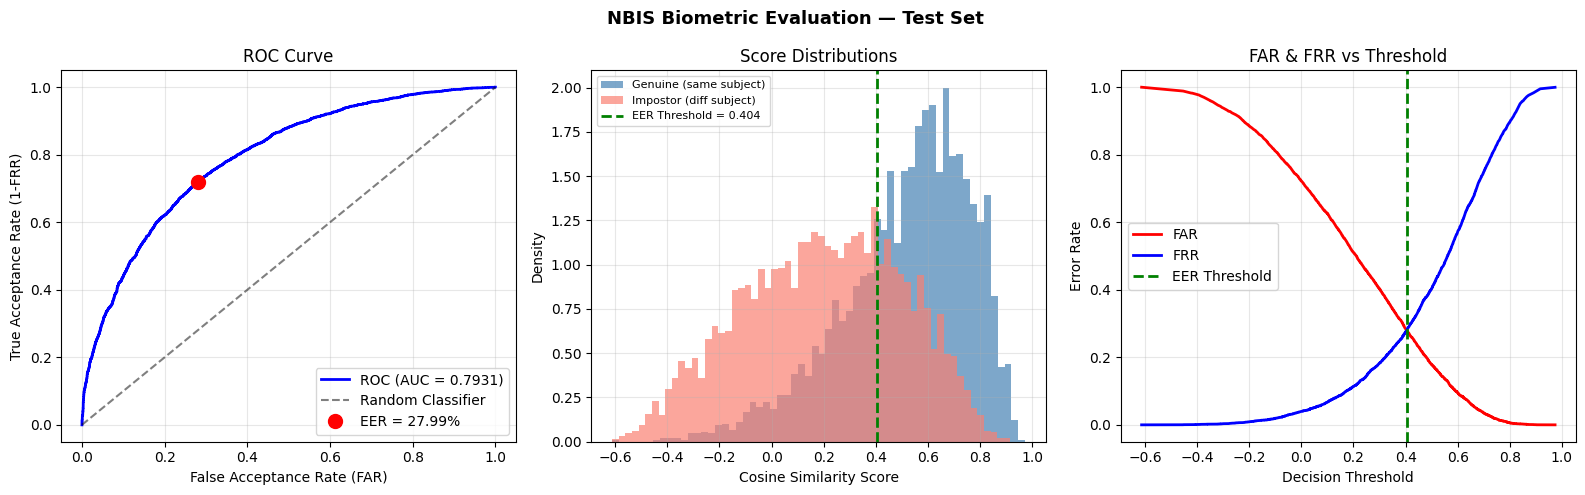

In [24]:
def plot_evaluation(metrics: dict, genuine_scores: np.ndarray, impostor_scores: np.ndarray):
    """Plot ROC curve and score distribution histograms."""
    fig = plt.figure(figsize=(16, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # ── ROC Curve ──────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(metrics['fpr'], metrics['tpr'], 'b-', linewidth=2,
             label=f'ROC (AUC = {metrics["auc"]:.4f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    eer_idx = np.argmin(np.abs(metrics['far'] - metrics['frr']))
    ax1.plot(metrics['fpr'][eer_idx], metrics['tpr'][eer_idx],
             'ro', markersize=10, label=f'EER = {metrics["eer"]*100:.2f}%')
    ax1.set_xlabel('False Acceptance Rate (FAR)')
    ax1.set_ylabel('True Acceptance Rate (1-FRR)')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # ── Score Distribution ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.hist(genuine_scores,  bins=60, alpha=0.7, color='steelblue',
             label='Genuine (same subject)',  density=True)
    ax2.hist(impostor_scores, bins=60, alpha=0.7, color='salmon',
             label='Impostor (diff subject)', density=True)
    ax2.axvline(metrics['eer_threshold'], color='green', linestyle='--',
                linewidth=2, label=f'EER Threshold = {metrics["eer_threshold"]:.3f}')
    ax2.set_xlabel('Cosine Similarity Score')
    ax2.set_ylabel('Density')
    ax2.set_title('Score Distributions')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── FAR / FRR vs Threshold ─────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    thresh_plot = metrics['thresholds']
    ax3.plot(thresh_plot, metrics['far'], 'r-', linewidth=2, label='FAR')
    ax3.plot(thresh_plot, metrics['frr'], 'b-', linewidth=2, label='FRR')
    ax3.axvline(metrics['eer_threshold'], color='green', linestyle='--',
                linewidth=2, label=f'EER Threshold')
    ax3.set_xlabel('Decision Threshold')
    ax3.set_ylabel('Error Rate')
    ax3.set_title('FAR & FRR vs Threshold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    fig.suptitle('NBIS Biometric Evaluation — Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'evaluation_metrics.png'), dpi=150)
    plt.show()


plot_evaluation(metrics, genuine_scores, impostor_scores)

---
## Section 13 — Threshold Selection

The optimal threshold is set at the **Equal Error Rate (EER)** point,  
where FAR = FRR. This is the standard operating point for biometric systems.

In [49]:
print('=' * 55)
print('  NBIS — Optimal Threshold Summary')
print('=' * 55)
print(f'  Threshold (EER)  : {metrics["eer_threshold"]:.6f}')
print(f'  FAR @ Threshold  : {metrics["far"][np.argmin(np.abs(metrics["far"] - metrics["frr"]))] * 100:.2f}%')
print(f'  FRR @ Threshold  : {metrics["frr"][np.argmin(np.abs(metrics["far"] - metrics["frr"]))] * 100:.2f}%')
print(f'  EER              : {metrics["eer"] * 100:.2f}%')
print(f'  ROC-AUC          : {metrics["auc"]:.4f}')
print('=' * 55)




  NBIS — Optimal Threshold Summary
  Threshold (EER)  : 0.407723
  FAR @ Threshold  : 28.52%
  FRR @ Threshold  : 28.49%
  EER              : 28.51%
  ROC-AUC          : 0.7880


---
## Section 14 — Inference Function (FAISS-based)

Given a new fingerprint image, the system:
1. Preprocesses the image
2. Computes the embedding via the trained model
3. L2-normalizes the embedding
4. Searches the FAISS index for the top-k nearest neighbors
5. Returns subject info, parent info, and similarity score

In [34]:
def identify_fingerprint(
    image_path: str,
    model: Model,
    index: faiss.Index,
    mapping: list[dict],
    threshold: float,
    img_size: tuple = (224, 224),
    top_k: int = 3
) -> dict:
    """
    Identify a fingerprint image against the FAISS index.

    Args:
        image_path : path to the fingerprint image
        model      : trained embedding model
        index      : FAISS index (IndexFlatIP)
        mapping    : list of dicts mapping FAISS idx → subject/parent info
        threshold  : decision threshold (cosine similarity)
        img_size   : image input size
        top_k      : number of nearest neighbors to retrieve

    Returns:
        dict with identification result
    """
    # Step 1: Preprocess
    img_arr = preprocess_image(image_path, img_size)          # (H, W, 3)
    img_batch = np.expand_dims(img_arr, 0).astype(np.float32) # (1, H, W, 3)

    # Step 2: Compute embedding
    embedding = model.predict(img_batch, verbose=0)            # (1, emb_dim)

    # Step 3: L2 normalize
    emb_norm = embedding.astype(np.float32).copy()
    faiss.normalize_L2(emb_norm)

    # Step 4: Search FAISS index
    scores, indices = index.search(emb_norm, top_k)           # (1, k), (1, k)
    top_score = float(scores[0][0])
    top_idx   = int(indices[0][0])

    # Step 5: Threshold decision
    if top_score >= threshold:
        match = mapping[top_idx]
        result = {
            'status'        : 'MATCH',
            'confidence'    : f'{top_score * 100:.2f}%',
            'subject_id'    : match['subject_id'],
            'parent_id'     : match['parent_id'],
            'parent_name'   : match['full_name'],
            'parent_phone'  : match['phone'],
            'parent_email'  : match['email'],
            'city'          : match['city'],
            'similarity'    : top_score,
            'threshold_used': threshold,
            'top_k_results' : [
                {
                    'rank'      : r + 1,
                    'subject_id': mapping[int(indices[0][r])]['subject_id'],
                    'score'     : float(scores[0][r])
                }
                for r in range(min(top_k, len(scores[0])))
            ]
        }
    else:
        result = {
            'status'        : 'NO MATCH',
            'confidence'    : f'{top_score * 100:.2f}%',
            'subject_id'    : None,
            'similarity'    : top_score,
            'threshold_used': threshold,
            'message'       : 'Similarity below threshold. Identity could not be verified.'
        }

    return result


print('✅ Inference function defined.')

✅ Inference function defined.


## Testing The Model

In [37]:
# ─── Demo Inference on a test image ──────────────────────────────────────────
test_sample = df_test.sample(1, random_state=99).iloc[0]
test_image_path = test_sample['path']

print(f'Query image: {test_image_path}')
print(f'True subject_id: {test_sample["subject_id"]}')

result = identify_fingerprint(
    image_path = test_image_path,
    model      = best_model,
    index      = faiss_inference,        # ← updated
    mapping    = mapping_inference,      # ← updated
    threshold  = OPTIMAL_THRESHOLD,
    img_size   = CONFIG['img_size'],
    top_k      = 5
)

print('\n' + '=' * 50)
print('  IDENTIFICATION RESULT')
print('=' * 50)
for key, val in result.items():
    if key != 'top_k_results':
        print(f'  {key:<20}: {val}')
print('\n  Top-K Matches:')
if 'top_k_results' in result:
    for r in result['top_k_results']:
        print(f'    Rank {r["rank"]}: Subject {r["subject_id"]} — Score {r["score"]:.4f}')
print('=' * 50)

Query image: /content/Real/42__F_Left_ring_finger.BMP
True subject_id: 042

  IDENTIFICATION RESULT
  status              : MATCH
  confidence          : 100.00%
  subject_id          : 042
  parent_id           : P0042
  parent_name         : Noha Badawi
  parent_phone        : +20101049999
  parent_email        : noha.badawi86@gmail.com
  city                : Hurghada
  similarity          : 1.000000238418579
  threshold_used      : 0.40772300958633423

  Top-K Matches:
    Rank 1: Subject 042 — Score 1.0000
    Rank 2: Subject 042 — Score 0.9305
    Rank 3: Subject 439 — Score 0.9139
    Rank 4: Subject 038 — Score 0.9138
    Rank 5: Subject 225 — Score 0.8995


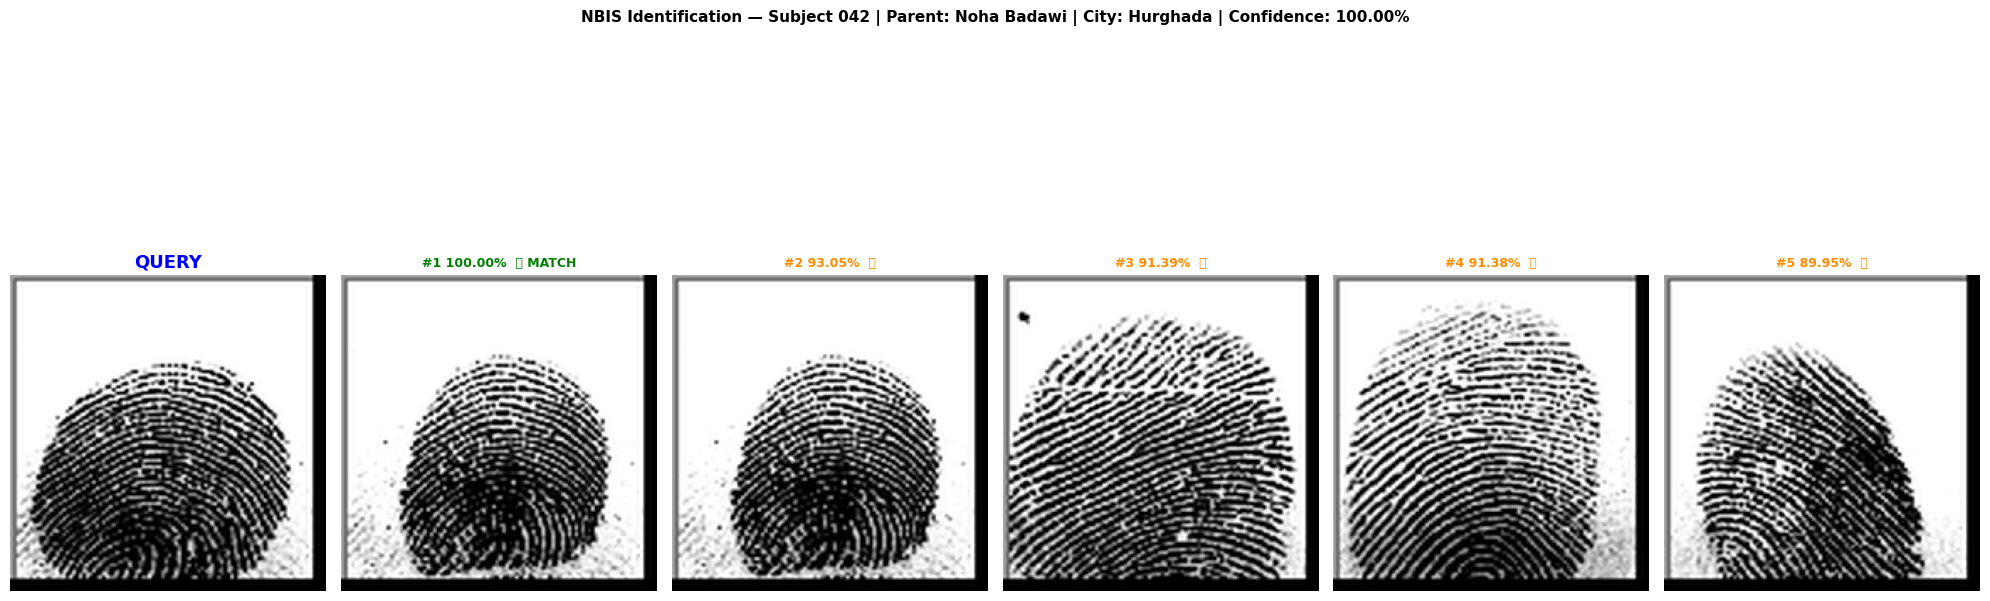

✅ Saved: ./nbis_artifacts/identification_result.png


In [46]:
def visualize_identification_result(
    query_path: str,
    result: dict,
    mapping: list[dict],
    img_size: tuple,
    top_k: int = 5
):
    """
    Visualize query fingerprint alongside top-K matches with full parent info.
    """
    top_k_results = result.get('top_k_results', [])

    fig = plt.figure(figsize=(20, 8))
    gs  = gridspec.GridSpec(1, top_k + 1, figure=fig)

    # ── Query image ───────────────────────────────────────────────────────────
    ax_query = fig.add_subplot(gs[0])
    query_img = preprocess_image(query_path, img_size)
    ax_query.imshow(query_img[:, :, 0], cmap='gray')
    ax_query.set_title('QUERY', fontweight='bold', fontsize=13, color='blue')
    ax_query.axis('off')

    # Query info box below
    query_info = (
        f"Path: {query_path.split('/')[-1]}\n"
        f"True Subject: {result['subject_id']}"
    )
    ax_query.set_xlabel(query_info, fontsize=8, color='blue',
                        labelpad=10, ha='center')

    for spine in ax_query.spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(3)

    # ── Top-K matches ─────────────────────────────────────────────────────────
    for rank_idx, rank_result in enumerate(top_k_results):
        subject_id = rank_result['subject_id']
        score      = rank_result['score']

        # Find image for this subject
        subj_rows  = df_all[df_all['subject_id'] == subject_id]
        if len(subj_rows) == 0:
            continue
        match_path = subj_rows.iloc[0]['path']
        match_img  = preprocess_image(match_path, img_size)

        # Get parent info from mapping
        parent_info = next(
            (m for m in mapping if m['subject_id'] == subject_id), {}
        )

        # Get child info from df_subjects
        child_info  = df_subjects[
            df_subjects['subject_id'] == subject_id
        ]
        child_name  = child_info.iloc[0]['full_name'] if len(child_info) > 0 else 'N/A'
        child_gender= child_info.iloc[0]['gender']    if len(child_info) > 0 else 'N/A'

        color  = 'green' if rank_idx == 0 else 'darkorange'
        label  = f'#{rank_idx+1} {score*100:.2f}%  {"✅ MATCH" if rank_idx==0 else "❌"}'

        ax = fig.add_subplot(gs[rank_idx + 1])
        ax.imshow(match_img[:, :, 0], cmap='gray')
        ax.set_title(label, fontweight='bold', fontsize=9, color=color)
        ax.axis('off')

        # Full info box
        info_text = (
            f"✅ MATCH\n"
            f"Sub:{subject_id}  {subj_rows.iloc[0]['hand']} {subj_rows.iloc[0]['finger']}\n"
            f"Child : {child_name} ({child_gender})\n"
            f"Parent: {parent_info.get('full_name',  'N/A')}\n"
            f"NID   : {parent_info.get('national_id','N/A')}\n"
            f"Phone : {parent_info.get('phone',      'N/A')}\n"
            f"Email : {parent_info.get('email',      'N/A')}\n"
            f"City  : {parent_info.get('city',       'N/A')}"
        ) if rank_idx == 0 else (
            f"Sub:{subject_id}  {subj_rows.iloc[0]['hand']} {subj_rows.iloc[0]['finger']}\n"
            f"Child : {child_name} ({child_gender})\n"
            f"Parent: {parent_info.get('full_name',  'N/A')}\n"
            f"NID   : {parent_info.get('national_id','N/A')}\n"
            f"Phone : {parent_info.get('phone',      'N/A')}\n"
            f"Email : {parent_info.get('email',      'N/A')}\n"
            f"City  : {parent_info.get('city',       'N/A')}"
        )

        ax.set_xlabel(info_text, fontsize=7, color=color,
                      labelpad=10, ha='center', linespacing=1.6)

        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    fig.suptitle(
        f'NBIS Identification — Subject {result["subject_id"]} | '
        f'Parent: {result["parent_name"]} | '
        f'City: {result["city"]} | '
        f'Confidence: {result["confidence"]}',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(CONFIG['output_dir'], 'identification_result.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'✅ Saved: {CONFIG["output_dir"]}/identification_result.png')


# ─── Run ──────────────────────────────────────────────────────────────────────
visualize_identification_result(
    query_path = test_image_path,
    result     = result,
    mapping    = mapping_inference,
    img_size   = CONFIG['img_size'],
    top_k      = 5
)


In [35]:
# ─── Test on 20 images using INFERENCE index ─────────────────────────────────
correct   = 0
incorrect = 0
results   = []

test_samples = df_test.sample(20, random_state=42)

for _, row in test_samples.iterrows():
    result = identify_fingerprint(
        image_path = row['path'],
        model      = best_model,
        index      = faiss_inference,      # ← inference index
        mapping    = mapping_inference,    # ← inference mapping
        threshold  = OPTIMAL_THRESHOLD,
        img_size   = CONFIG['img_size'],
        top_k      = 5
    )

    true_id      = row['subject_id']
    predicted_id = result.get('subject_id', None)
    is_correct   = str(true_id).zfill(3) == str(predicted_id).zfill(3)

    if is_correct:
        correct += 1
    else:
        incorrect += 1

    results.append({
        'true_id'     : true_id,
        'predicted_id': predicted_id,
        'correct'     : '✅' if is_correct else '❌',
        'confidence'  : result.get('confidence', 'N/A'),
    })

print('=' * 60)
print('  Quick Accuracy Test — 20 Random Test Images')
print('=' * 60)
for r in results:
    print(f"  {r['correct']} True: {r['true_id']} | Predicted: {r['predicted_id']} | {r['confidence']}")
print('=' * 60)
print(f'  Correct   : {correct}/20 ({correct*5}%)')
print(f'  Incorrect : {incorrect}/20 ({incorrect*5}%)')
print('=' * 60)

  Quick Accuracy Test — 20 Random Test Images
  ✅ True: 043 | Predicted: 043 | 100.00%
  ✅ True: 556 | Predicted: 556 | 100.00%
  ✅ True: 168 | Predicted: 168 | 100.00%
  ✅ True: 438 | Predicted: 438 | 100.00%
  ✅ True: 014 | Predicted: 014 | 100.00%
  ✅ True: 529 | Predicted: 529 | 100.00%
  ✅ True: 196 | Predicted: 196 | 100.00%
  ✅ True: 066 | Predicted: 066 | 100.00%
  ✅ True: 043 | Predicted: 043 | 100.00%
  ✅ True: 050 | Predicted: 050 | 100.00%
  ✅ True: 077 | Predicted: 077 | 100.00%
  ✅ True: 376 | Predicted: 376 | 100.00%
  ✅ True: 550 | Predicted: 550 | 100.00%
  ✅ True: 070 | Predicted: 070 | 100.00%
  ✅ True: 519 | Predicted: 519 | 100.00%
  ✅ True: 443 | Predicted: 443 | 100.00%
  ✅ True: 112 | Predicted: 112 | 100.00%
  ✅ True: 304 | Predicted: 304 | 100.00%
  ✅ True: 315 | Predicted: 315 | 100.00%
  ✅ True: 042 | Predicted: 042 | 100.00%
  Correct   : 20/20 (100%)
  Incorrect : 0/20 (0%)


---
## Section 15 — Embedding Distance Visualization

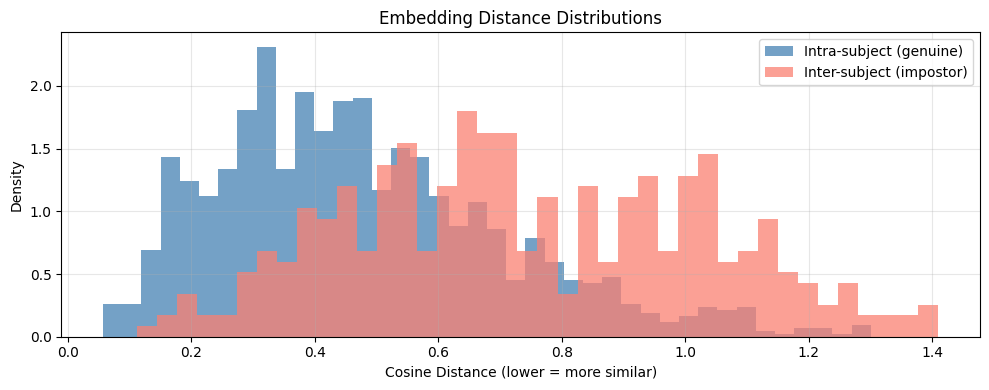

In [38]:
def visualize_embedding_distances(test_embeddings, df_test, n_subjects=10):
    """
    Visualize intra-subject vs inter-subject cosine distance distributions
    for a subset of test subjects.
    """
    embs = test_embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    subject_ids   = df_test['subject_id'].values
    unique_subjs  = df_test['subject_id'].unique()[:n_subjects]

    subj_to_idx = defaultdict(list)
    for i, sid in enumerate(subject_ids):
        subj_to_idx[sid].append(i)

    intra_dists = []
    inter_dists = []

    for sid in unique_subjs:
        idxs = subj_to_idx[sid]
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                sim = np.dot(embs[idxs[i]], embs[idxs[j]])
                intra_dists.append(1 - sim)

        other_subjs = [s for s in unique_subjs if s != sid]
        for osid in random.sample(list(other_subjs), min(3, len(other_subjs))):
            for oi in subj_to_idx[osid][:2]:
                for ai in idxs[:2]:
                    sim = np.dot(embs[ai], embs[oi])
                    inter_dists.append(1 - sim)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(intra_dists, bins=40, alpha=0.75, color='steelblue',
            label='Intra-subject (genuine)', density=True)
    ax.hist(inter_dists, bins=40, alpha=0.75, color='salmon',
            label='Inter-subject (impostor)', density=True)
    ax.set_xlabel('Cosine Distance (lower = more similar)')
    ax.set_ylabel('Density')
    ax.set_title('Embedding Distance Distributions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'embedding_distances.png'), dpi=150)
    plt.show()


# ← updated: use more subjects for richer visualization
visualize_embedding_distances(test_embeddings, df_test, n_subjects=30)

In [47]:
correct   = 0
incorrect = 0
results   = []

print('Testing on ALL 900 test images...')
for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    result = identify_fingerprint(
        image_path = row['path'],
        model      = best_model,
        index      = faiss_inference,
        mapping    = mapping_inference,
        threshold  = OPTIMAL_THRESHOLD,
        img_size   = CONFIG['img_size'],
        top_k      = 1
    )

    true_id      = row['subject_id']
    predicted_id = result.get('subject_id', None)
    is_correct   = str(true_id).zfill(3) == str(predicted_id).zfill(3)

    if is_correct:
        correct += 1
    else:
        incorrect += 1

print('=' * 60)
print('  Full Accuracy Test — 900 Test Images')
print('=' * 60)
print(f'  Correct   : {correct}/900 ({correct/900*100:.2f}%)')
print(f'  Incorrect : {incorrect}/900 ({incorrect/900*100:.2f}%)')
print('=' * 60)

Testing on ALL 900 test images...


100%|██████████| 900/900 [01:21<00:00, 11.06it/s]

  Full Accuracy Test — 900 Test Images
  Correct   : 898/900 (99.78%)
  Incorrect : 2/900 (0.22%)


---
## Section 16 — Save Artifacts

In [39]:
def save_artifacts(
    model: Model,
    faiss_index: faiss.Index,
    mapping: list[dict],
    threshold: float,
    config: dict,
    output_dir: str
):

    os.makedirs(output_dir, exist_ok=True)

    # 1. Model
    model_path = os.path.join(output_dir, 'nbis_embedding_model.keras')
    model.save(model_path)
    print(f'✅ Model saved       : {model_path}')

    # 2. FAISS index
    index_path = os.path.join(output_dir, 'nbis_faiss.index')
    faiss.write_index(faiss_index, index_path)
    print(f'✅ FAISS index saved : {index_path}')

    # 3. Subject-parent mapping
    mapping_path = os.path.join(output_dir, 'nbis_index_mapping.pkl')
    with open(mapping_path, 'wb') as f:
        pickle.dump(mapping, f)
    print(f'✅ Mapping saved     : {mapping_path}')

    # 4. Threshold
    threshold_path = os.path.join(output_dir, 'nbis_threshold.json')
    with open(threshold_path, 'w') as f:
        json.dump({'eer_threshold': float(threshold)}, f, indent=2)
    print(f'✅ Threshold saved   : {threshold_path}')

    # 5. Preprocessing config
    prep_config = {
        'img_size'      : list(config['img_size']),
        'embedding_dim' : config['embedding_dim'],
        'color_mode'    : 'grayscale_stacked_3ch',
        'normalization' : 'divide_by_255',
        'l2_normalize'  : True,
    }
    prep_path = os.path.join(output_dir, 'nbis_preprocessing_config.json')
    with open(prep_path, 'w') as f:
        json.dump(prep_config, f, indent=2)
    print(f'✅ Preproc config    : {prep_path}')

    print(f'\n🎉 All NBIS artifacts saved to: {output_dir}/')


save_artifacts(
    model      = best_model,
    faiss_index= faiss_index,
    mapping    = index_mapping,
    threshold  = OPTIMAL_THRESHOLD,
    config     = CONFIG,
    output_dir = CONFIG['output_dir'],
)

✅ Model saved       : ./nbis_artifacts/nbis_embedding_model.keras
✅ FAISS index saved : ./nbis_artifacts/nbis_faiss.index
✅ Mapping saved     : ./nbis_artifacts/nbis_index_mapping.pkl
✅ Threshold saved   : ./nbis_artifacts/nbis_threshold.json
✅ Preproc config    : ./nbis_artifacts/nbis_preprocessing_config.json

🎉 All NBIS artifacts saved to: ./nbis_artifacts/


---
## Section 17 — Loading Artifacts for Deployment

This section demonstrates how to reload all artifacts in a new session for production inference.

In [41]:
def load_nbis_system(output_dir: str) -> tuple:
    """
    Load all NBIS artifacts from disk for deployment.
    Returns:
        (model, faiss_index, mapping, threshold, prep_config)
    """
    # Model — rebuild architecture then load weights
    model = build_embedding_network_v2(
        img_size      = tuple(CONFIG['img_size']),
        embedding_dim = CONFIG['embedding_dim']
    )
    model.load_weights(
        os.path.join(output_dir, 'nbis_embedding_model.keras')
    )

    # FAISS index
    index = faiss.read_index(
        os.path.join(output_dir, 'nbis_faiss.index')
    )

    # Mapping
    with open(os.path.join(output_dir, 'nbis_index_mapping.pkl'), 'rb') as f:
        mapping = pickle.load(f)

    # Threshold
    with open(os.path.join(output_dir, 'nbis_threshold.json')) as f:
        threshold = json.load(f)['eer_threshold']

    # Preprocessing config
    with open(os.path.join(output_dir, 'nbis_preprocessing_config.json')) as f:
        prep_config = json.load(f)

    print('✅ NBIS system loaded from disk:')
    print(f'   Model input   : {prep_config["img_size"]}')
    print(f'   Embedding dim : {prep_config["embedding_dim"]}')
    print(f'   FAISS vectors : {index.ntotal}')
    print(f'   Threshold     : {threshold:.6f}')

    return model, index, mapping, threshold, prep_config


# ─── Verify reload ────────────────────────────────────────────────────────────
loaded_model, loaded_index, loaded_mapping, loaded_threshold, loaded_prep = \
    load_nbis_system(CONFIG['output_dir'])

# ─── Confirm inference works with loaded artifacts ────────────────────────────
result_reload = identify_fingerprint(
    image_path = test_image_path,
    model      = loaded_model,
    index      = loaded_index,
    mapping    = loaded_mapping,
    threshold  = loaded_threshold,
    img_size   = tuple(loaded_prep['img_size']),
)

print(f'\n✅ Reload test:')
print(f'   Status     : {result_reload["status"]}')
print(f'   Score      : {result_reload["similarity"]:.4f}')
print(f'   Subject ID : {result_reload["subject_id"]}')
print(f'   Parent     : {result_reload["parent_name"]}')
print(f'   City       : {result_reload["city"]}')

✅ NBIS system loaded from disk:
   Model input   : [224, 224]
   Embedding dim : 128
   FAISS vectors : 6000
   Threshold     : 0.407723

✅ Reload test:
   Status     : MATCH
   Score      : 1.0000
   Subject ID : 042
   Parent     : Noha Badawi
   City       : Hurghada


In [40]:
# ─── Save artifacts with inference index ─────────────────────────────────────
save_artifacts(
    model       = best_model,
    faiss_index = faiss_inference,
    mapping     = mapping_inference,
    threshold   = OPTIMAL_THRESHOLD,
    config      = CONFIG,
    output_dir  = CONFIG['output_dir'],
)

# ─── Backup to Drive ──────────────────────────────────────────────────────────
from google.colab import drive, files
import shutil

drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/NBIS'
os.makedirs(DRIVE_PATH, exist_ok=True)

for item in os.listdir(CONFIG['output_dir']):
    src = os.path.join(CONFIG['output_dir'], item)
    dst = os.path.join(DRIVE_PATH, item)
    if os.path.isfile(src):
        shutil.copy(src, dst)

shutil.copytree(
    '/content/nbis_database',
    f'{DRIVE_PATH}/nbis_database',
    dirs_exist_ok=True
)
print('✅ Everything backed up to Drive!')

# ─── Download all artifacts to PC ─────────────────────────────────────────────
print('\nDownloading artifacts...')
files.download('./nbis_artifacts/nbis_embedding_model.keras')
files.download('./nbis_artifacts/nbis_faiss.index')
files.download('./nbis_artifacts/nbis_index_mapping.pkl')
files.download('./nbis_artifacts/nbis_threshold.json')
files.download('./nbis_artifacts/nbis_preprocessing_config.json')
files.download('/content/nbis_database/nbis.db')
files.download('/content/nbis_database/parents.csv')
files.download('/content/nbis_database/subjects.csv')
files.download('/content/nbis_database/images.csv')
print('✅ All files downloading to your PC!')

✅ Model saved       : ./nbis_artifacts/nbis_embedding_model.keras
✅ FAISS index saved : ./nbis_artifacts/nbis_faiss.index
✅ Mapping saved     : ./nbis_artifacts/nbis_index_mapping.pkl
✅ Threshold saved   : ./nbis_artifacts/nbis_threshold.json
✅ Preproc config    : ./nbis_artifacts/nbis_preprocessing_config.json

🎉 All NBIS artifacts saved to: ./nbis_artifacts/
Mounted at /content/drive
✅ Everything backed up to Drive!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloading to your PC!


---
## Summary & Artifact Index

| Artifact | File | Description |
|---|---|---|
| Trained Model | `nbis_embedding_model.keras` | MobileNetV2 + Triplet head |
| Best Checkpoint | `nbis_best_model.keras` | Saved at lowest val loss |
| FAISS Index | `nbis_faiss.index` | IndexFlatIP, cosine similarity |
| ID Mapping | `nbis_index_mapping.pkl` | FAISS idx → subject/parent info |
| Threshold | `nbis_threshold.json` | EER-based decision threshold |
| Preprocessing | `nbis_preprocessing_config.json` | Reproducible preprocessing |
| Training Plot | `training_history.png` | Loss curves |
| Evaluation Plot | `evaluation_metrics.png` | ROC / Score dist / FAR-FRR |
| Distance Plot | `embedding_distances.png` | Intra vs inter subject |

---

## Academic Limitations & Future Work

1. **Dataset Domain Gap**: SOCOFing contains adult fingerprints (ages 18+). Newborn fingerprints have significantly smaller ridge spacing (~3–5× smaller) and softer textures. The model should be fine-tuned on neonatal data before clinical deployment.

2. **Dual Modality**: The current implementation uses fingerprints only. The full NBIS architecture proposes combined fingerprint + footprint matching via late fusion.

3. **Online Hard Triplet Mining**: For improved training efficiency, triplets should be mined online using semi-hard or hard mining within each batch rather than offline generation.

4. **Longitudinal Stability**: Infant biometrics change rapidly over weeks. A temporal re-enrollment protocol is recommended at 2-week intervals for the first 3 months.

5. **Deployment Security**: In production, embeddings must never be stored as raw vectors; a biometric template protection scheme (e.g., cancelable biometrics or fuzzy commitment) must be applied.